# Interval edge colouring with z3 -- fastest encoding only

Five independent z3 optimizations (on top of `faster_version_reencoded.ipynb`'s
incremental push/pop + window-encoding baseline) were benchmarked head-to-head on a
genuinely hard instance: `K(2,2,3)`, which has **no** interval colouring up to 10
colours at all, so every technique has to fully prove `unsat` for k = 5..10.

Total wall-clock to prove that:

| variant | total time (s) |
|---|---|
| baseline (push/pop, Int) | 22.73 |
| symmetry breaking only | 15.66 |
| assumptions only | 11.34 |
| BitVec only | 4.80 |
| **BitVec + assumptions + symmetry (combined)** | **1.21** |

The combined technique won outright (~19x faster than baseline), so this notebook
keeps only that encoding -- no more re-running the same search 5 times just to
compare variants.

## 0. Graph + edge helpers (unchanged from the base notebook)

In [15]:
import time
import pygraphviz as pgv
from z3 import *


def create_graph(l, m, n):
    """Edges of the complete tripartite graph K(l, m, n)."""
    edges = []
    for i in range(0, l):
        for j in range(l, l + m):
            edges.append((i, j))
    for i in range(0, l):
        for k in range(l + m, l + m + n):
            edges.append((i, k))
    for j in range(l, l + m):
        for k in range(l + m, l + m + n):
            edges.append((j, k))
    return edges


def build_graph(l, m, n):
    """Build the AGraph for K(l, m, n). Returns (graph, name, layout)."""
    G = pgv.AGraph()
    G.node_attr['style'] = 'filled'
    G.edge_attr['dir'] = 'none'

    edges = create_graph(l, m, n)
    for i in range(l + m + n):
        G.add_node(i)
    for src, dst in edges:
        G.add_edge(src, dst)

    return (G, 'k_%d_%d_%d' % (l, m, n), 'circo')


def all_edges(graph):
    """All edges of `graph` as 'a b' strings."""
    return [u + ' ' + v for u, v in graph.edges()]


def incidence(edges):
    """vertex -> list of indices of edges touching it."""
    inc = {}
    for i, e in enumerate(edges):
        u, v = e.split(' ')
        inc.setdefault(u, []).append(i)
        inc.setdefault(v, []).append(i)
    return inc


## 1. The solver -- BitVec + assumptions + symmetry breaking

Three independent techniques stacked into one solver:

- **BitVec colours** instead of Int -- the colour domain is small and bounded, so
  Z3 bit-blasts straight to SAT instead of doing Simplex case-splits for every
  `Distinct` pair.
- **`check()` assumptions** instead of `push()`/`pop()` for the per-k upper bound --
  avoids solver-trail/scope bookkeeping on every k tried.
- **Symmetry breaking**: colours are only meaningful up to a constant shift, so
  `Or([x == 0 for x in xs])` pins the minimum colour to 0, collapsing every
  solution's whole shift-equivalent family into a single representative.

**Correctness note (BitVec wraparound):** `width` is sized with headroom
(`2 * max_colors`), and both `x` and `lo` (the per-vertex window start) are
explicitly fenced to `[0, max_colors - 1]`, so no arithmetic here can reach the
wraparound boundary.

In [16]:
def interval_coloring(graph, max_colors=None):
    """Interval edge colouring with z3 -- BitVec colours, assumption-based k
    search, and the minimum-colour-is-0 symmetry break. The fastest of five
    encodings benchmarked; see the notebook intro for numbers.

    Returns a result dict:
      {'solution': {edge:colour} or None, 'colorable': bool,
       'colours': k or None, 'colours_tested': int,
       'delta': int, 'max_colors': int}
    """
    edges = all_edges(graph)
    idx = {e: i for i, e in enumerate(edges)}
    inc = incidence(edges)

    delta = max(len(es) for es in inc.values())
    if max_colors is None:
        max_colors = 2 * delta

    width = max(4, (2 * max_colors).bit_length() + 2)
    xs = [BitVec('e%d' % i, width) for i in range(len(edges))]

    s = Solver()
    for x in xs:
        s.add(x >= 0, x <= max_colors - 1)
    s.add(Or([x == 0 for x in xs]))
    for v, es in inc.items():
        vs = [xs[i] for i in es]
        s.add(Distinct(vs))
        if len(vs) > 1:
            lo = BitVec('lo_%s' % v, width)
            s.add(lo >= 0, lo <= max_colors - 1)
            for x in vs:
                s.add(x >= lo, x <= lo + (len(vs) - 1))

    tested = 0
    for k in range(delta, max_colors + 1):
        tested += 1
        if s.check([x <= k - 1 for x in xs]) == sat:
            m = s.model()
            sol = {e: m[xs[idx[e]]].as_long() for e in edges}
            return {'solution': sol, 'colorable': True, 'colours': k,
                    'colours_tested': tested, 'delta': delta, 'max_colors': max_colors}

    return {'solution': None, 'colorable': False, 'colours': None,
            'colours_tested': tested, 'delta': delta, 'max_colors': max_colors}

## 2. Profiled version -- same stats table as `faster_version_reencoded.ipynb`

`interval_coloring_profiled` is `interval_coloring` with `Solver.statistics()`
captured (and printed) after every `check()` call: the same `k / sat / time(s) /
decisions / conflicts / propagations / restarts` table that section 4b of
`faster_version_reencoded.ipynb` prints for its baseline, so a row here and the
matching row there are directly comparable.

In [17]:
def _profile_search(s, xs, idx, edges, delta, max_colors, verbose=True):
    """Assumption-based k-loop + Solver.statistics() capture."""
    if verbose:
        print('%-4s %-6s %-8s %-10s %-10s %-13s %-9s' %
              ('k', 'sat', 'time(s)', 'decisions', 'conflicts', 'propagations', 'restarts'))
    stats = []
    for k in range(delta, max_colors + 1):
        t0 = time.time()
        outcome = s.check([x <= k - 1 for x in xs])
        elapsed = time.time() - t0

        st = s.statistics()
        d = {key: st.get_key_value(key) for key in st.keys()}
        row = {'k': k, 'sat': outcome == sat, 'time': elapsed,
               'decisions': d.get('decisions', 0), 'conflicts': d.get('conflicts', 0),
               'propagations': d.get('propagations', 0), 'restarts': d.get('restarts', 0)}
        stats.append(row)
        if verbose:
            print('%-4d %-6s %-8.4f %-10d %-10d %-13d %-9d' %
                  (row['k'], row['sat'], row['time'], row['decisions'],
                   row['conflicts'], row['propagations'], row['restarts']))

        if outcome == sat:
            m = s.model()
            sol = {e: m[xs[idx[e]]].as_long() for e in edges}
            return {'solution': sol, 'colorable': True, 'colours': k,
                    'colours_tested': len(stats), 'delta': delta, 'max_colors': max_colors}, stats

    return {'solution': None, 'colorable': False, 'colours': None,
            'colours_tested': len(stats), 'delta': delta, 'max_colors': max_colors}, stats


def interval_coloring_profiled(graph, max_colors=None, verbose=True):
    """Same encoding as interval_coloring (BitVec + assumptions + symmetry
    breaking), but records/prints Solver.statistics() for every k.

    Returns (res, stats) -- res matches interval_coloring's return value;
    stats is a list of one dict per k tried: {'k', 'sat', 'time', 'decisions',
    'conflicts', 'propagations', 'restarts'}.
    """
    edges = all_edges(graph)
    idx = {e: i for i, e in enumerate(edges)}
    inc = incidence(edges)
    delta = max(len(es) for es in inc.values())
    if max_colors is None:
        max_colors = 2 * delta

    width = max(4, (2 * max_colors).bit_length() + 2)
    xs = [BitVec('e%d' % i, width) for i in range(len(edges))]

    s = Solver()
    for x in xs:
        s.add(x >= 0, x <= max_colors - 1)
    s.add(Or([x == 0 for x in xs]))
    for v, es in inc.items():
        vs = [xs[i] for i in es]
        s.add(Distinct(vs))
        if len(vs) > 1:
            lo = BitVec('lo_%s' % v, width)
            s.add(lo >= 0, lo <= max_colors - 1)
            for x in vs:
                s.add(x >= lo, x <= lo + (len(vs) - 1))

    return _profile_search(s, xs, idx, edges, delta, max_colors, verbose)

## 3. Solution → matrix

`color_matrix` turns an edge-colour solution into a matrix, `*` marks cells with no edge, including the diagonal. `format_matrix` renders it as aligned text for saving/printing. `log_solution` appends a run's summary + matrix to `solutions.txt`, the same way `faster_version_reencoded.ipynb` does.

In [18]:
def color_matrix(graph, solution):
    """edge-colour matrix; '*' where there is no edge."""
    nodes = sorted(graph.nodes(), key=int)
    idx = {node: i for i, node in enumerate(nodes)}
    M = [['*'] * len(nodes) for _ in nodes]
    for e_str, color in solution.items():
        u, v = e_str.split(' ')
        M[idx[u]][idx[v]] = str(color)
        M[idx[v]][idx[u]] = str(color)
    return nodes, M


def format_matrix(nodes, M):
    """Render the matrix as aligned text with node labels on row/col."""
    w = max([len(x) for row in M for x in row] + [len(x) for x in nodes]) + 1
    lines = [' ' * w + ''.join(x.rjust(w) for x in nodes)]
    for label, row in zip(nodes, M):
        lines.append(label.rjust(w) + ''.join(x.rjust(w) for x in row))
    return '\n'.join(lines)


def format_kmn(name, solution):
    """
    Rows = part A (size l) then part B (size m); columns = part A (size l)
    then part C (size n). '*' marks no-edge cells (the A x A block).
    """
    l, m, n = (int(t) for t in name.split('_')[1:])
    row_nodes = [str(v) for v in range(l + m)]                              # A, then B
    col_nodes = [str(v) for v in list(range(l)) + list(range(l + m, l + m + n))]  # A, then C

    def cell(u, v):
        c = solution.get(u + ' ' + v)
        if c is None:
            c = solution.get(v + ' ' + u)
        return '*' if c is None else str(c)

    grid = [[cell(r, c) for c in col_nodes] for r in row_nodes]
    w = max(len(x) for row in grid for x in row)
    rows_txt = [' ' + ' | '.join(x.rjust(w) for x in row) + ' |' for row in grid]
    width = max(len(r) for r in rows_txt)
    rule = ' ' + '-' * (width - 1)

    lines = [('K ' + ' '.join(str(s) for s in (l, m, n))).center(width), '']
    for r in rows_txt:
        lines.append(r)
        lines.append(rule)
    return '\n'.join(lines)


def render_matrix(name, graph, solution):
    parts = name.split('_')
    if parts[0] == 'k' and len(parts) == 4 and all(p.isdigit() for p in parts[1:]):
        return format_kmn(name, solution)
    nodes, M = color_matrix(graph, solution)
    return format_matrix(nodes, M)


def log_solution(name, graph, res, runtime, path='solutions.txt'):
    """Append a summary of one run to the combined solutions file: runtime,
    how many colour-counts were tested, whether the graph was colourable, and
    (if so) the solution matrix appends.
    Entries accumulate across runs."""

    lo = res['delta']
    hi = lo + res['colours_tested'] - 1
    lines = ['=== %s ===' % name,
             'colourable     : %s' % ('yes' if res['colorable'] else 'no'),
             'colours tested : %d  (k = %d .. %d)' % (res['colours_tested'], lo, hi),
             'runtime        : %.3f s' % runtime]
    if res['colorable']:
        lines.append('colours used   : %d' % res['colours'])
        lines.append('solution matrix:')
        lines.append(render_matrix(name, graph, res['solution']))
    lines.append('')
    with open(path, 'a') as f:
        f.write('\n'.join(lines) + '\n')
    print('Appended result for %s to %s' % (name, path))

## 4. Run

Build K(l, m, n) and colour its edges with `interval_coloring_profiled`, printing
the per-k solver-effort table followed by a summary.

In [34]:
l,m,n = 2,2,7

In [ ]:
G, gname, _ = build_graph(l, m, n)
print('Solving %s with the combined encoding (BitVec + assumptions + symmetry-breaking)' % gname)
print()

t1 = time.time()
res, stats = interval_coloring_profiled(G)
t2 = time.time()
runtime = t2 - t1

print()
if res['colorable']:
    print('Minimum colours for an interval colouring: %d' % res['colours'])
    print('  (max degree Delta = %d is a hard lower bound)' % res['delta'])
else:
    print('No interval colouring found with up to %d colours' % res['max_colors'])
print('Colour counts tested: %d (searched upward from Delta)' % res['colours_tested'])
print('Total solve time: %.4fs' % sum(row['time'] for row in stats))

# save this run to the combined solutions file
log_solution(gname, G, res, runtime)

Solving k_2_2_7 with the combined encoding (BitVec + assumptions + symmetry-breaking)

k    sat    time(s)  decisions  conflicts  propagations  restarts 
9    False  898.2214 1642268    1337515    281952110     1355     


## 4b. Per-k solver effort (visualizing the search)

`interval_coloring_profiled` already records `Solver.statistics()` for every
`k` it tries (section 2) -- this just charts the `stats` list instead of only
printing it. Green bars are `sat` calls, red bars are `unsat` calls; on a hard
instance like `K(2,2,7)` almost all the height should be red, since proving a
`k` too small is what actually costs time -- the eventual `sat` call that
finds the answer is comparatively cheap.

In [ ]:
import matplotlib.pyplot as plt

ks = [d['k'] for d in stats]
times = [d['time'] for d in stats]
decisions = [d['decisions'] for d in stats]
conflicts = [d['conflicts'] for d in stats]
bar_colors = ['#2ca02c' if d['sat'] else '#d62728' for d in stats]   # green = sat, red = unsat

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].bar(ks, times, color=bar_colors)
axes[0].set_ylabel('time (s)')
axes[0].set_title('Per-k solver effort for %s   (green = sat, red = unsat)' % gname)

width = 0.4
axes[1].bar([k - width / 2 for k in ks], decisions, width=width, color=bar_colors, alpha=0.9, label='decisions')
axes[1].bar([k + width / 2 for k in ks], conflicts, width=width, color=bar_colors, alpha=0.4, label='conflicts')
# spans several orders of magnitude on hard instances -> try axes[1].set_yscale('log') then
axes[1].set_ylabel('count')
axes[1].set_xlabel('k (number of colours tried)')
axes[1].set_xticks(ks)
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Draw the coloured graph

Draws the graph with each part on its own row (same colour per row) and edges coloured + labelled with their colour number. Change `part_fill` for the node/row colours and `edge_palette` for the edge colours.

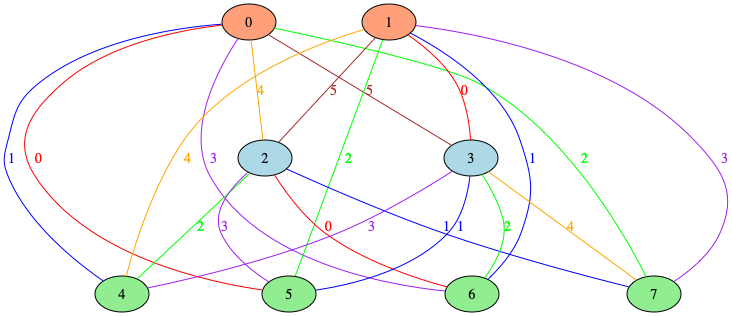

In [ ]:
# Draw the coloured graph: nodes coloured by part (same row = same colour).
# Layout rules:
#   * every part sits on its own horizontal line,
#   * the part with the FEWEST nodes is pinned to the TOP (2 nodes on top),
#   * the part with the MOST nodes is pinned to the BOTTOM,
#   * generous spacing + spline routing so nodes never overlap and edges
#     curve AROUND nodes instead of crossing over them,
#   * edges coloured and labelled with their colour number.
if not res['colorable']:
    print('No colouring to draw for %s.' % gname)
else:
    sol = res['solution']
    sizes = [int(t) for t in gname.split('_')[1:]]      # 'k_2_3_4' -> [2, 3, 4]

    # >>> CHANGE NODE COLOURS HERE (one per row/part) <<<
    part_fill = ['lightsalmon', 'lightblue', 'lightgreen', 'khaki', 'plum']
    # >>> CHANGE EDGE COLOURS HERE (indexed by each edge's colour number) <<<
    edge_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown',
                    'cyan', 'magenta', 'darkgreen', 'gray', 'gold', 'navy']

    # node index range for each ORIGINAL part: part p owns nodes [start, start+size)
    starts, node = [], 0
    for size in sizes:
        starts.append(node)
        node += size
    part_nodes_by_part = [[str(starts[p] + i) for i in range(sizes[p])]
                          for p in range(len(sizes))]

    # vertical order of the rows: smallest part on TOP, largest part on BOTTOM
    row_order = sorted(range(len(sizes)), key=lambda p: sizes[p])
    n_rows = len(row_order)

    # spacing so nodes never overlap and edges have room to route AROUND nodes
    G.graph_attr['nodesep'] = '0.6'    # horizontal gap between nodes in a row
    G.graph_attr['ranksep'] = '1.2'    # vertical gap between rows (room for splines)
    G.graph_attr['splines'] = 'true'   # draw edges as curves that avoid nodes

    for row_pos, p in enumerate(row_order):
        part_nodes = part_nodes_by_part[p]
        for nd in part_nodes:
            n = G.get_node(nd)
            n.attr['style'] = 'filled'
            n.attr['fillcolor'] = part_fill[p % len(part_fill)]
        # top row -> rank 'min', bottom row -> rank 'max', middle rows -> 'same'
        rank = 'min' if row_pos == 0 else ('max' if row_pos == n_rows - 1 else 'same')
        sub = G.add_subgraph(part_nodes, name='row_%d' % row_pos, rank=rank)
        # invisible chain keeps the row in increasing left-to-right order
        for a, b in zip(part_nodes, part_nodes[1:]):
            sub.add_edge(a, b, style='invis')

    # colour AND number each edge
    for e_str, color in sol.items():
        u, v = e_str.split(' ')
        e = G.get_edge(u, v)
        c = edge_palette[color % len(edge_palette)]
        e.attr['color'] = c
        e.attr['fontcolor'] = c
        e.attr['label'] = str(color)

    from IPython.display import Image, display
    # prog='dot' forces the layered engine that stacks the rows.
    # (pygraphviz's draw() defaults to neato, which would scramble the rows.)
    display(Image(G.draw(prog='dot', format='png')))   # show inline (NOT saved to disk)

## 6. Save graph + matrix to HTML

Same as `faster_version_reencoded.ipynb`'s HTML export: appends a section to
`solutions.html` with the run's stats, the solution matrix, and the coloured
graph image (base64-embedded PNG, using the same row layout as section 5).

In [28]:
import base64

png_bytes = G.draw(prog='dot', format='png')
out_path  = 'solutions.html'

html = ['<section style="font-family:monospace;text-align:center;'
        'max-width:800px;margin:24px auto;'
        'border-bottom:1px solid #ccc;padding-bottom:16px">']
html.append('<h2>%s</h2>' % gname)

# each field on its own line
html.append('<div>colourable: <b>%s</b></div>' % ('yes' if res['colorable'] else 'no'))
if res['colorable']:
    html.append('<div>colours used: <b>%d</b></div>' % res['colours'])
    html.append('<div>runtime: %.3f s</div>' % runtime)
    # solution matrix
    html.append('<pre style="background:#f6f6f6;padding:8px;'
                'display:inline-block;text-align:left">%s</pre>'
                % render_matrix(gname, G, res['solution']))
    # image
    b64 = base64.b64encode(png_bytes).decode('ascii')
    html.append('<div><img src="data:image/png;base64,%s" '
                'style="max-width:640px;border:1px solid #ddd"></div>' % b64)
html.append('</section>')

with open(out_path, 'a') as f:
    f.write('\n'.join(html) + '\n')
print('saved image + matrix ->', out_path)

saved image + matrix -> solutions.html
